# Realty Price Prediction

This notebook is dedicating to cleaning and conducting initial EDA on real property data, scraped from [realtor.com](realtor.com). 

## Data Overview:

**Data Captured between:**
04/01/2022 - 05/25/2022

**Data Coverage:**
United States of America

<br>

**realtor-data.csv (2,226,382 entries)**

- brokered by (categorically encoded agency/broker)

- status (Housing status - a. ready for sale or b. ready to build)

- price (Housing price, it is either the current listing price or recently sold price if the house is sold recently)

- bed (# of beds)

- bath (# of bathrooms)

- acre_lot (Property / Land size in acres)

- street (categorically encoded street address)

- city (city name)

- state (state name)

- zip_code (postal code of the area)

- house_size (house area/size/living space in square feet)

- prev_sold_date (Previously sold date)

## License & Disclaimer

Data was collected from -

https://www.realtor.com/ - A real estate listing website operated by the News Corp subsidiary Move, Inc. and based in Santa Clara, California. It is the second most visited real estate listing website in the United States as of 2024, with over 100 million monthly active users.

I do not own any data, and all rights are reserved to the respective owners.

# Loading

In [125]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
# loading data + head
df = pd.read_csv('../data/realtor-data.csv')
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [127]:
# changing column name 'zip_code' to 'postal_code'
df.rename(columns={'zip_code': 'postal_code'}, inplace=True)
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [128]:
# filtering for new york; using fuzzy string matching to find all variations of 'New York' in the 'state' column (just in case there are any mispells, etc.)
from rapidfuzz import fuzz
target = 'New York'
df['state_similarity'] = df['state'].apply(lambda x: fuzz.ratio(x, target))
df_ny = df[df['state_similarity'] > 80]

# dropping state_similarity column from df_ny
df_ny.drop(columns='state_similarity', inplace=True)

df_ny.head()

/var/folders/gs/yv3dj4zx2tgdd5tw701ypspm0000gp/T/ipykernel_2389/4023655186.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ny.drop(columns='state_similarity', inplace=True)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date
5217,10368.0,for_sale,175000.0,3.0,1.0,60.00,553526.0,Berlin,New York,12022.0,1176.0,NaN
7970,22006.0,for_sale,425000.0,3.0,2.0,2.02,263302.0,Claverack,New York,12521.0,1600.0,2021-11-24
7975,48310.0,for_sale,225000.0,4.0,2.0,0.24,871278.0,Copake,New York,12521.0,1239.0,2018-02-01
7976,7797.0,for_sale,419000.0,3.0,3.0,1.90,286373.0,Copake,New York,12516.0,1800.0,NaN
7977,23402.0,for_sale,365000.0,3.0,2.0,2.00,78544.0,Copake,New York,12517.0,1482.0,NaN


<Axes: >

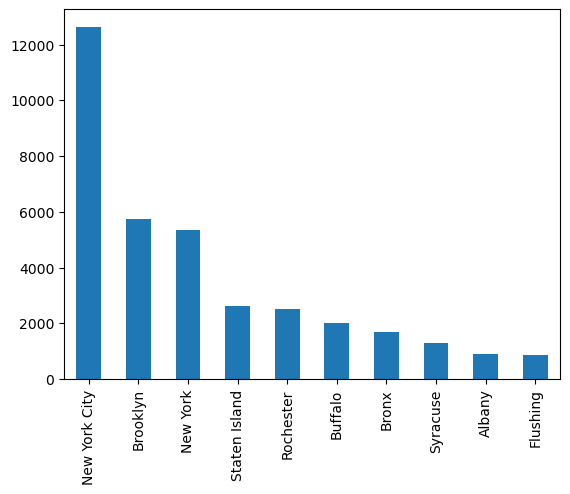

In [129]:
# Looking at top 10 cities with most listings
df_ny['city'].value_counts()[:10].plot(kind='bar')

In [130]:
df_ny.describe()

,brokered_by,price,bed,bath,acre_lot,street,postal_code,house_size
count,103028.000000,1.031570e+05,86911.000000,89954.000000,73870.000000,1.021810e+05,103138.000000,72965.000000
mean,47556.979355,9.437968e+05,3.238796,2.304256,72.404475,9.702402e+05,12095.353972,1977.246214
std,28624.139690,3.672641e+06,1.932273,1.600848,1951.820181,5.533160e+05,1526.592075,2272.208046
min,32.000000,0.000000e+00,1.000000,1.000000,0.000000,5.500000e+01,4715.000000,4.000000
25%,23592.000000,1.825000e+05,2.000000,1.000000,0.110000,5.100950e+05,11206.000000,1150.000000
50%,42758.500000,4.200000e+05,3.000000,2.000000,0.250000,9.586430e+05,11934.000000,1618.000000
75%,67986.000000,8.490000e+05,4.000000,3.000000,1.000000,1.437630e+06,13203.000000,2300.000000
max,110111.000000,8.750000e+08,142.000000,123.000000,100000.000000,2.001247e+06,99999.000000,352836.000000


***

# Cleaning

Using the data wrangler extension, I'm able to see that there are several data quality issues:


### Missingness
- Missing rows for almost all columns. Most importantly:

    - Bed
    - Bath
    - Price
    - House Size
    - Acre Lot

- House Size & Acre Lot have almost 30% of their data missing. Must decide whether to impute/flag/drop.

### Logical
- state column has 55 unique values, despite only 50 U.S. states
    - (no issue). 5 Additional "States" are Guam, Virgin Islands, New Brunswick, Puerto Rico, and District of Columbia.

- No concrete geospatial data, like coordinates. 

- Street is encoded for privacy purposes (No issue).

- Acre lot has most values below 5000. Many are between 0 and 1.

### Aggregations
- bath column has a max of 123. Highly unlikely.

- bed column has a max of 142. Highly unlikely.

- Price has values of 0. Uninterpretable.

### Data Types
- Convert to integer:
    - price(?)
    - bed
    - bath
    - house size(?)

    > (?) means I need to check if there are any decimal values that aren't 0 in these columns, before I commit to converting them to integer.



In [132]:
df['state'].unique()

array(['Puerto Rico', 'Virgin Islands', 'Massachusetts', 'Connecticut',
       'New Hampshire', 'Vermont', 'New Jersey', 'New York',
       'South Carolina', 'Tennessee', 'Rhode Island', 'Virginia',
       'Wyoming', 'Maine', 'Georgia', 'Pennsylvania', 'West Virginia',
       'Delaware', 'Louisiana', 'Ohio', 'California', 'Colorado',
       'Maryland', 'Missouri', 'District of Columbia', 'Wisconsin',
       'North Carolina', 'Kentucky', 'Michigan', 'Mississippi', 'Florida',
       'Alabama', 'New Brunswick', nan, 'Texas', 'Arkansas', 'Idaho',
       'Indiana', 'Illinois', 'New Mexico', 'Iowa', 'Minnesota',
       'South Dakota', 'Nebraska', 'North Dakota', 'Montana', 'Oklahoma',
       'Kansas', 'Oregon', 'Utah', 'Nevada', 'Washington', 'Arizona',
       'Hawaii', 'Guam', 'Alaska'], dtype=object)

In [133]:
# Check missingness
missing = df_ny.isnull().mean().sort_values(ascending=False)
print("Missingness by column:\n", missing)

# Drop rows with critical missing values
critical_cols = ['bed', 'bath', 'price', 'house_size', 'acre_lot']
df_ny = df_ny.dropna(subset=critical_cols)
display(df_ny.head())
display(df_ny.shape)
display(df_ny.describe())

Missingness by column:
 prev_sold_date    0.340271
house_size        0.292694
acre_lot          0.283921
bed               0.157504
bath              0.128006
street            0.009481
brokered_by       0.001270
postal_code       0.000204
city              0.000126
price             0.000019
status            0.000000
state             0.000000
dtype: float64


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date
5217,10368.0,for_sale,175000.0,3.0,1.0,60.00,553526.0,Berlin,New York,12022.0,1176.0,NaN
7970,22006.0,for_sale,425000.0,3.0,2.0,2.02,263302.0,Claverack,New York,12521.0,1600.0,2021-11-24
7975,48310.0,for_sale,225000.0,4.0,2.0,0.24,871278.0,Copake,New York,12521.0,1239.0,2018-02-01
7976,7797.0,for_sale,419000.0,3.0,3.0,1.90,286373.0,Copake,New York,12516.0,1800.0,NaN
7977,23402.0,for_sale,365000.0,3.0,2.0,2.00,78544.0,Copake,New York,12517.0,1482.0,NaN


(50967, 12)

,brokered_by,price,bed,bath,acre_lot,street,postal_code,house_size
count,50931.000000,5.096700e+04,50967.000000,50967.000000,50967.000000,5.076400e+04,50962.000000,50967.000000
mean,50097.098899,6.688417e+05,3.618243,2.451743,96.659633,9.393341e+05,12672.580884,2100.683992
std,28211.649251,1.906157e+06,1.661390,1.565112,2322.376979,5.271879e+05,1329.680327,2367.095873
min,32.000000,1.000000e+00,1.000000,1.000000,0.000000,1.586000e+03,6390.000000,122.000000
25%,26990.000000,1.680000e+05,3.000000,2.000000,0.110000,4.934390e+05,11733.000000,1312.000000
50%,45875.000000,3.000000e+05,3.000000,2.000000,0.240000,9.396055e+05,12570.000000,1746.000000
75%,70353.000000,6.499000e+05,4.000000,3.000000,0.720000,1.395181e+06,14004.000000,2400.000000
max,110111.000000,1.690000e+08,75.000000,113.000000,100000.000000,2.000843e+06,18650.000000,352836.000000


In [134]:
# Handle outliers for bed, price, acre_lot, and house_size (IQR Method)
# (handling bath separately, since bathrooms can have different outlier thresholds)

for col in ['bed', 'price', 'acre_lot', 'house_size']:
    Q1 = df_ny[col].quantile(0.25)
    Q3 = df_ny[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_ny = df_ny[(df_ny[col] >= lower_bound) & (df_ny[col] <= upper_bound)]

display(df_ny.head())
display(df_ny.describe())
print("Shape after outlier removal:", df_ny.shape)

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date
7975,48310.0,for_sale,225000.0,4.0,2.0,0.24,871278.0,Copake,New York,12521.0,1239.0,2018-02-01
7984,32016.0,for_sale,375000.0,3.0,2.0,1.20,1427842.0,Millerton,New York,12546.0,1350.0,2018-08-31
8035,26779.0,for_sale,194900.0,4.0,3.0,1.29,1431678.0,Nassau,New York,12123.0,2274.0,NaN
8036,10211.0,for_sale,40000.0,2.0,1.0,0.20,1202236.0,Nassau,New York,12123.0,690.0,2005-12-01
8037,10368.0,for_sale,125000.0,3.0,2.0,1.00,1531619.0,Hoosick Falls,New York,12090.0,980.0,NaN


,brokered_by,price,bed,bath,acre_lot,street,postal_code,house_size
count,34594.000000,3.462600e+04,34626.000000,34626.000000,34626.000000,3.455200e+04,34623.000000,34626.000000
mean,50721.130572,3.477770e+05,3.259169,2.085254,0.308325,9.338860e+05,12839.322069,1671.701149
std,27865.487613,2.650846e+05,0.794788,0.814460,0.308132,5.285994e+05,1317.669908,549.547107
min,170.000000,1.000000e+00,2.000000,1.000000,0.000000,4.453000e+03,10000.000000,122.000000
25%,28985.000000,1.499000e+05,3.000000,2.000000,0.110000,4.832112e+05,11937.000000,1255.000000
50%,45888.000000,2.499000e+05,3.000000,2.000000,0.200000,9.246070e+05,12866.000000,1584.000000
75%,70880.500000,4.990000e+05,4.000000,3.000000,0.390000,1.394027e+06,14120.000000,2004.000000
max,110111.000000,1.250000e+06,5.000000,25.000000,1.560000,2.000273e+06,14905.000000,3274.000000


Shape after outlier removal: (34626, 12)


Max bathrooms are now 25 after handling other outliers. Let's just do a simple case study to see if these are viable values of bathrooms.

In [135]:
# looking at bathrooms > 10
bath_outliers = df_ny[df_ny['bath'] > 10]
bath_outliers.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date
1481511,33754.0,sold,450000.0,3.0,25.0,0.06,1072236.0,Woodstock,New York,12498.0,1905.0,2021-11-23


While none of the information about this listing indicates it being false, it's better to drop this row as to not mess with the model.

In [136]:
# dropping row where bath = 25
df_ny = df_ny[df_ny['bath'] <= 10]
df_ny.shape

(34625, 12)

In [137]:
# Checking if there are real decimal values in price and house_size, or if they are just integers stored as floats
print("Unique price values (sample):", df_ny['price'].unique()[:10])
print("Unique house_size values (sample):", df_ny['house_size'].unique()[:10])

# converting to integer
int_col = ['price', 'bed', 'bath', 'house_size']

for col in int_col:
    df_ny[col] = df_ny[col].astype(int)

df_ny.head()

Unique price values (sample): [225000. 375000. 194900.  40000. 125000. 299900. 379500.  61900. 123000.
  92500.]
Unique house_size values (sample): [1239. 1350. 2274.  690.  980. 1608. 2080. 1344. 1386. 1056.]


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date
7975,48310.0,for_sale,225000,4,2,0.24,871278.0,Copake,New York,12521.0,1239,2018-02-01
7984,32016.0,for_sale,375000,3,2,1.20,1427842.0,Millerton,New York,12546.0,1350,2018-08-31
8035,26779.0,for_sale,194900,4,3,1.29,1431678.0,Nassau,New York,12123.0,2274,NaN
8036,10211.0,for_sale,40000,2,1,0.20,1202236.0,Nassau,New York,12123.0,690,2005-12-01
8037,10368.0,for_sale,125000,3,2,1.00,1531619.0,Hoosick Falls,New York,12090.0,980,NaN


***

# Exploratory Data Analysis

We'll be conducting some quick aggregations and analyses to find initial trends, findings, etc. I will check:

- Distributions of each viable feature

- Aggregations (min, max, avg, mode, median)

- Trends for each feature against our y variable (price)

In [138]:
df_ny.columns

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'postal_code', 'house_size', 'prev_sold_date'],
      dtype='object')

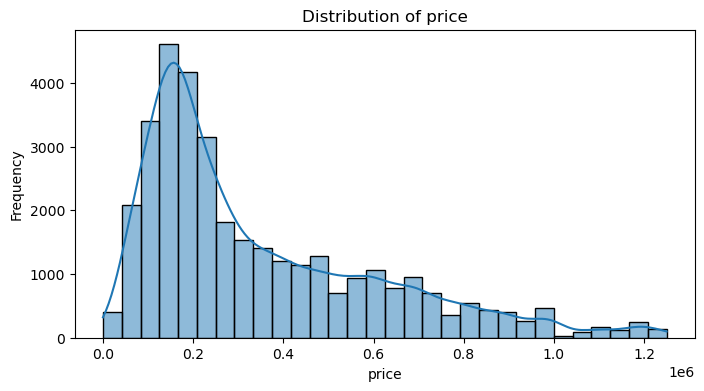

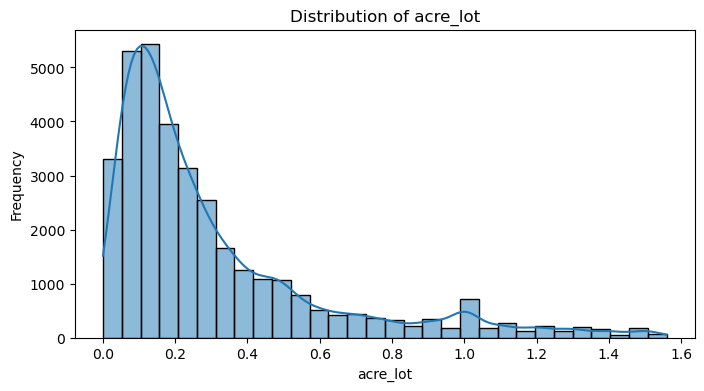

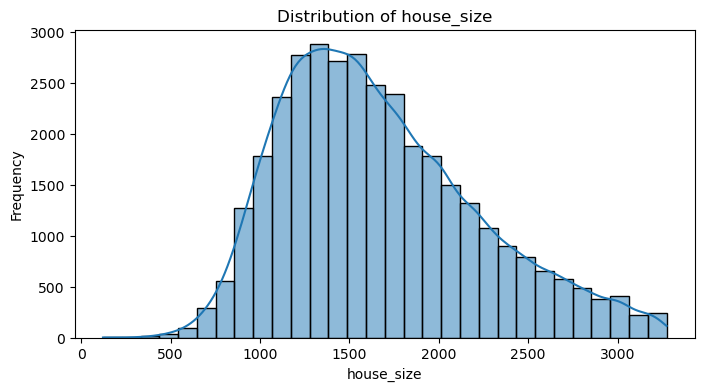

In [139]:
# distributions for target variable & potential features
dist_cols = ['price', 'acre_lot', 'house_size']

for col in dist_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_ny[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

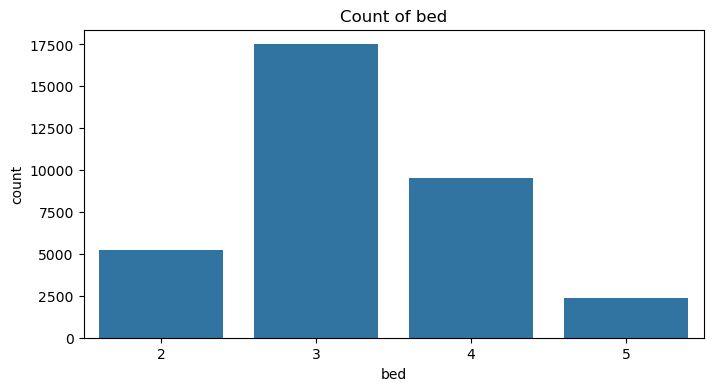

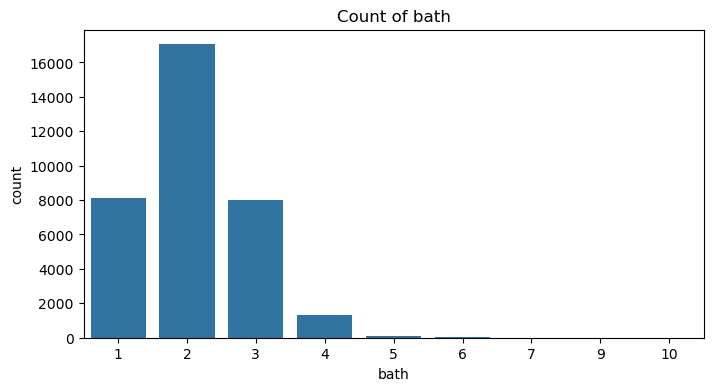

In [140]:
# bar plot of bed and bath columns
bar_cols = ['bed', 'bath']
for col in bar_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df_ny)
    plt.title(f'Count of {col}')


In [141]:
# getting shape of only New York City listings
nyc_shape = df[df['city'] == 'New York City'].shape
# shape of all ny listings
ny_shape = df_ny.shape

print(f'Shape of NY listings: {ny_shape}')
print(f'Shape of NYC listings: {nyc_shape}')

Shape of NY listings: (34625, 12)
Shape of NYC listings: (12634, 13)


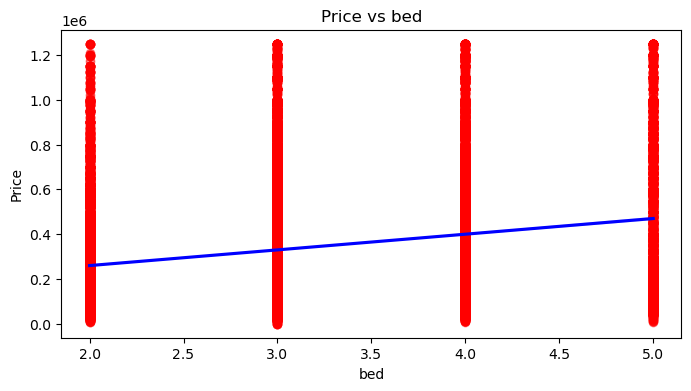

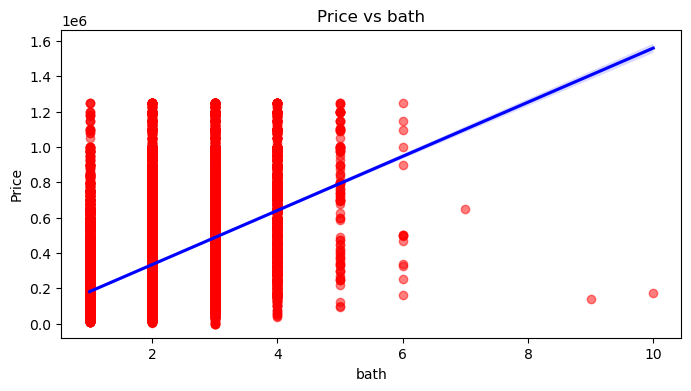

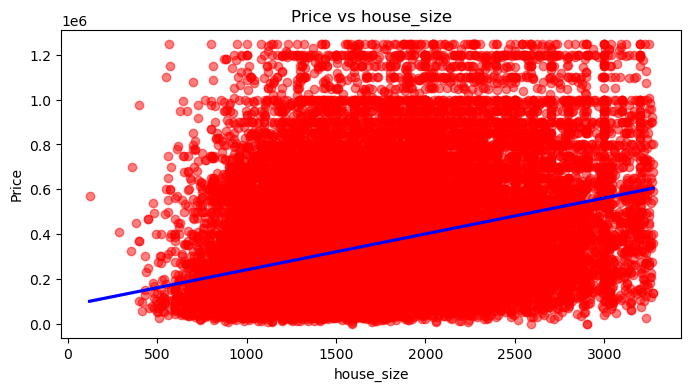

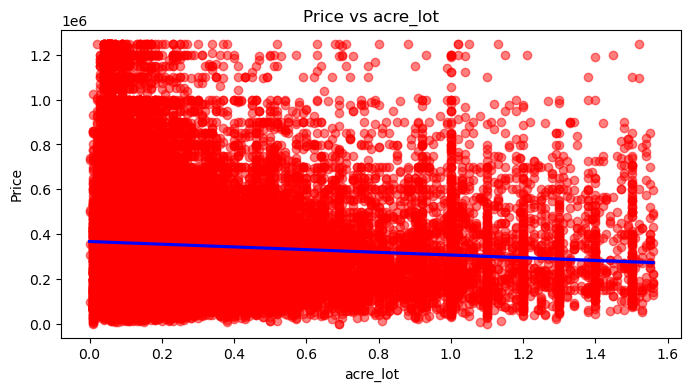

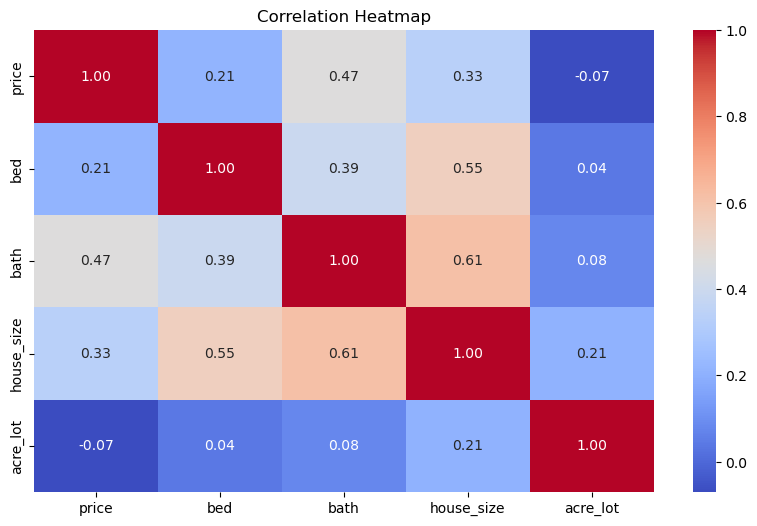

In [142]:
# finally, let's look at the correlation between numeric features and the target variable (price)
# This will be with scatter plots with a regression line, and a correlation heatmap

numeric_cols = ['bed', 'bath', 'house_size', 'acre_lot']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.regplot(x=col, y='price', data=df_ny, scatter_kws={'alpha':0.5}, color='red', line_kws={'color':'blue'})
    plt.title(f'Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.show()

# correlation heatmap
plt.figure(figsize=(10, 6))
corr = df_ny[['price', 'bed', 'bath', 'house_size', 'acre_lot']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Distributions and Correlations show some items that we were suspecting: Bed and Bath have positive correlations with increasing price of home. 

However, there is no single "powerful" feature. In other words, These feature may contribute to variation in price of home, but it's hard to account for much of it. I suspect spatial data may be more powerful indicators of price of home.

# Spatial Analysis + Targeting Encoding Cities

We're going to use target encoding, which is assigning the average price for cities with multiple entries. Since there are 1499+ unique cities, our aim with target encoding is to keep the dataset compact and handle high-cardinality of cities, all while capturing the relationships between prices and cities.

However, one problem is that there are a substancial amount of cities with < 2 listings. For this, we'll have to use smoothing by blending city averages with the overall average price of all cities.

In [143]:
# counting unique city values in df_ny
print("Unique cities in NY dataset:", df_ny['city'].nunique())

Unique cities in NY dataset: 1479


In [144]:
# bottom half of value counts for city column
print("Bottom half of city value counts:\n", df_ny['city'].value_counts()[len(df_ny['city'].value_counts())//2:])

Bottom half of city value counts:
 Cold Brook            6
Long Lake             6
Berne                 6
Marietta              6
Palatine Bridge       6
                     ..
Stillwater Village    1
Greenvile Center      1
Shinnecock Hills      1
Bridgehampton         1
Genesee               1
Name: city, Length: 740, dtype: int64


In [145]:
# Target encoding for 'city' column
# calculate overall mean price
overall_mean_price = df_ny['price'].mean()

# grouping city by price, aggregating by mean and count
city_stats = df_ny.groupby('city')['price'].agg(['mean', 'count'])
city_stats['overall_mean'] = overall_mean_price

alpha = 10  # smoothing strength

city_stats['city_te'] = (city_stats['mean'] * city_stats['count'] + overall_mean_price * alpha) / (city_stats['count'] + alpha)

# Apply target encoding to create new column
df_ny['city_te'] = round(df_ny['city'].map(city_stats['city_te']), 2)

df_ny.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,postal_code,house_size,prev_sold_date,city_te
7975,48310.0,for_sale,225000,4,2,0.24,871278.0,Copake,New York,12521.0,1239,2018-02-01,372566.93
7984,32016.0,for_sale,375000,3,2,1.20,1427842.0,Millerton,New York,12546.0,1350,2018-08-31,298882.86
8035,26779.0,for_sale,194900,4,3,1.29,1431678.0,Nassau,New York,12123.0,2274,NaN,259020.00
8036,10211.0,for_sale,40000,2,1,0.20,1202236.0,Nassau,New York,12123.0,690,2005-12-01,259020.00
8037,10368.0,for_sale,125000,3,2,1.00,1531619.0,Hoosick Falls,New York,12090.0,980,NaN,194095.79


- city_stats['mean'] is the average price for each city.

- city_stats['count'] is the number of data points for each city.

- overall_mean_price is the average price across all cities.

- Formula combines the city's mean (weighted by its count) and the overall mean (weighted by 10, which acts as a smoothing parameter).

- Denominator (city_stats['count'] + 10) ensures that cities with few listings are pulled closer to the overall mean, while cities with many listings rely more on their own mean.

***

## Final Check: Correlation Chart & Correlation Matrix for our new target encoded variable

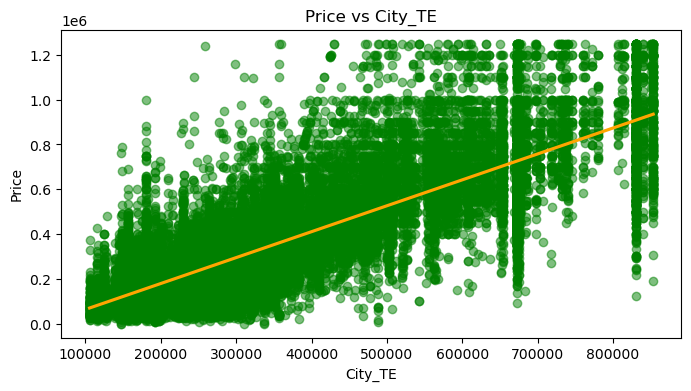

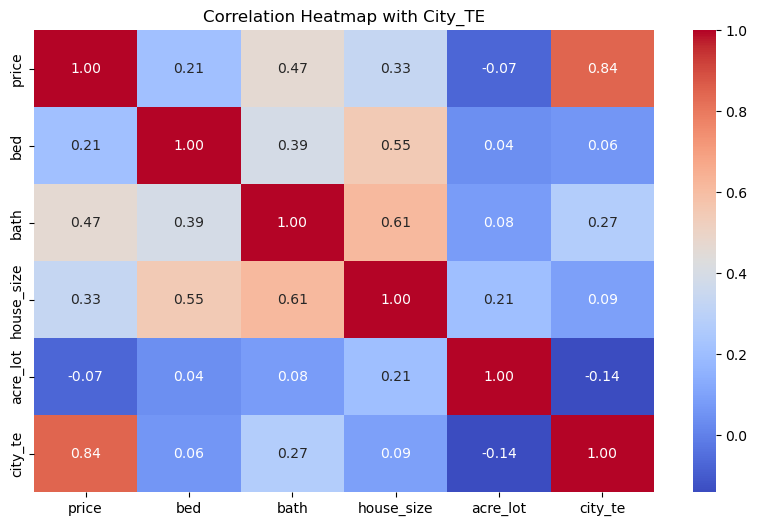

In [146]:
# corr chart and corr heatmap for new variable: city_te

# Corr chart
plt.figure(figsize=(8, 4))
sns.regplot(x='city_te', y='price', data=df_ny, scatter_kws={'alpha':0.5}, color='green', line_kws={'color':'orange'}) 
plt.title('Price vs City_TE')
plt.xlabel('City_TE')
plt.ylabel('Price')
plt.show()

# Corr Heatmap
plt.figure(figsize=(10, 6))
corr = df_ny[['price', 'bed', 'bath', 'house_size', 'acre_lot', 'city_te']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap with City_TE')
plt.show()

Bingo. This feature appears to be our most powerful driver of prices of home. Makes sense as well.

Now, sending to csv and moving on to modeling.

In [147]:
df_ny.to_csv('../data/cleaned_ny_listings.csv', index=False)